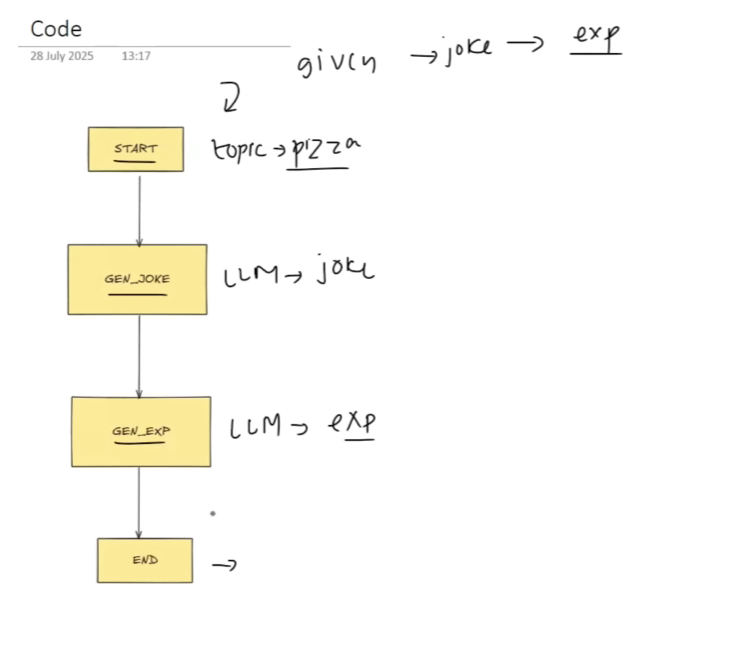

In [1]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv
from langgraph.checkpoint.memory import InMemorySaver

In [2]:
load_dotenv()

llm = ChatOpenAI()

In [3]:
class JokeState(TypedDict):

    topic: str
    joke: str
    explanation: str

In [4]:
def generate_joke(state: JokeState):

    prompt = f'generate a joke on the topic {state["topic"]}'
    response = llm.invoke(prompt).content

    return {'joke': response}

In [5]:
def generate_explanation(state: JokeState):

    prompt = f'write an explanation for the joke - {state["joke"]}'
    response = llm.invoke(prompt).content

    return {'explanation': response}

In [6]:
graph = StateGraph(JokeState)

graph.add_node('generate_joke', generate_joke)
graph.add_node('generate_explanation', generate_explanation)

graph.add_edge(START, 'generate_joke')
graph.add_edge('generate_joke', 'generate_explanation')
graph.add_edge('generate_explanation', END)

checkpointer = InMemorySaver()

workflow = graph.compile(checkpointer=checkpointer)

In [7]:
config1 = {"configurable": {"thread_id": "1"}}
workflow.invoke({'topic':'pizza'}, config=config1)

{'topic': 'pizza',
 'joke': 'Why did the pizza go to the party?\nBecause it knew it would be a "slice" hit!',
 'explanation': 'This joke plays on the double meaning of "slice." In the context of pizza, a "slice" refers to a portion of pizza that has been cut from the whole. By saying the pizza knew it would be a "slice" hit at the party, it is suggesting that the pizza knew it would be popular or well-received by the other party-goers. This is a play on the actual physical slice of pizza and the slang term "hit," which means something that is successful or enjoyable.'}

In [8]:
workflow.get_state(config1)

StateSnapshot(values={'topic': 'pizza', 'joke': 'Why did the pizza go to the party?\nBecause it knew it would be a "slice" hit!', 'explanation': 'This joke plays on the double meaning of "slice." In the context of pizza, a "slice" refers to a portion of pizza that has been cut from the whole. By saying the pizza knew it would be a "slice" hit at the party, it is suggesting that the pizza knew it would be popular or well-received by the other party-goers. This is a play on the actual physical slice of pizza and the slang term "hit," which means something that is successful or enjoyable.'}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f10fb50-e255-6d34-8002-41142756b414'}}, metadata={'source': 'loop', 'step': 2, 'parents': {}}, created_at='2026-02-22T06:09:32.602283+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f10fb50-d16c-64ca-8001-a354d523b11a'}}, tasks=(), interrupts=())

In [9]:
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'pizza', 'joke': 'Why did the pizza go to the party?\nBecause it knew it would be a "slice" hit!', 'explanation': 'This joke plays on the double meaning of "slice." In the context of pizza, a "slice" refers to a portion of pizza that has been cut from the whole. By saying the pizza knew it would be a "slice" hit at the party, it is suggesting that the pizza knew it would be popular or well-received by the other party-goers. This is a play on the actual physical slice of pizza and the slang term "hit," which means something that is successful or enjoyable.'}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f10fb50-e255-6d34-8002-41142756b414'}}, metadata={'source': 'loop', 'step': 2, 'parents': {}}, created_at='2026-02-22T06:09:32.602283+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f10fb50-d16c-64ca-8001-a354d523b11a'}}, tasks=(), interrupts=()),
 StateSnapsho

In [10]:
config2 = {"configurable": {"thread_id": "2"}}
workflow.invoke({'topic':'pasta'}, config=config2)

{'topic': 'pasta',
 'joke': "Why did the pasta go to the party alone? \nBecause it couldn't find a pasta-bility date!",
 'explanation': 'This joke plays on the pun between "pastability" (a play on the ability to attend an event) and a "pasta-bility" date (a play on a potential romantic partner). The humor comes from the silly idea of pasta trying to find a date and failing, ultimately deciding to go to the party alone. It is a light-hearted and playful joke that uses wordplay to create humor.'}

In [11]:
workflow.get_state(config1)

StateSnapshot(values={'topic': 'pizza', 'joke': 'Why did the pizza go to the party?\nBecause it knew it would be a "slice" hit!', 'explanation': 'This joke plays on the double meaning of "slice." In the context of pizza, a "slice" refers to a portion of pizza that has been cut from the whole. By saying the pizza knew it would be a "slice" hit at the party, it is suggesting that the pizza knew it would be popular or well-received by the other party-goers. This is a play on the actual physical slice of pizza and the slang term "hit," which means something that is successful or enjoyable.'}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f10fb50-e255-6d34-8002-41142756b414'}}, metadata={'source': 'loop', 'step': 2, 'parents': {}}, created_at='2026-02-22T06:09:32.602283+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f10fb50-d16c-64ca-8001-a354d523b11a'}}, tasks=(), interrupts=())

In [12]:
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'pizza', 'joke': 'Why did the pizza go to the party?\nBecause it knew it would be a "slice" hit!', 'explanation': 'This joke plays on the double meaning of "slice." In the context of pizza, a "slice" refers to a portion of pizza that has been cut from the whole. By saying the pizza knew it would be a "slice" hit at the party, it is suggesting that the pizza knew it would be popular or well-received by the other party-goers. This is a play on the actual physical slice of pizza and the slang term "hit," which means something that is successful or enjoyable.'}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f10fb50-e255-6d34-8002-41142756b414'}}, metadata={'source': 'loop', 'step': 2, 'parents': {}}, created_at='2026-02-22T06:09:32.602283+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f10fb50-d16c-64ca-8001-a354d523b11a'}}, tasks=(), interrupts=()),
 StateSnapsho

##### You see 4 stateSnapshot above because:
1. 1st snapshot is for the state before the __START__
2. 2nd snapshot--> before the 1st node
3. 3rd snapshot--> before the 2nd node
4. 4th snapshot --> before __END__


#### Time Travel

you can replay your workflow execution from spefici nodes. It comes handy when you are debugging. To run from that checkpoint, print all the snapshots which will show u the execution of all nodes, and then you can select the exact checkpoint_id of that node from where you want to debug or rerun the whole worlflow. So if u select Node 2 then it will start from Node 2 and execute the whole workflow until __END__

In [13]:
workflow.get_state({"configurable": {"thread_id": "1", "checkpoint_id": "1f10fb50-c09e-6d42-8000-aba296fb6612"}})

StateSnapshot(values={'topic': 'pizza'}, next=('generate_joke',), config={'configurable': {'thread_id': '1', 'checkpoint_id': '1f10fb50-c09e-6d42-8000-aba296fb6612'}}, metadata={'source': 'loop', 'step': 0, 'parents': {}}, created_at='2026-02-22T06:09:29.067032+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f10fb50-c09c-6d66-bfff-89937eb7738a'}}, tasks=(PregelTask(id='471d30d3-f1a1-9f6d-8ea4-6f94a90b2b2d', name='generate_joke', path=('__pregel_pull', 'generate_joke'), error=None, interrupts=(), state=None, result={'joke': 'Why did the pizza go to the party?\nBecause it knew it would be a "slice" hit!'}),), interrupts=())

##### Re-running the checkpoint 2 times below : 1f10fb50-c09e-6d42-8000-aba296fb6612

In [14]:
workflow.invoke(None, {"configurable": {"thread_id": "1", "checkpoint_id": "1f10fb50-c09e-6d42-8000-aba296fb6612"}})

{'topic': 'pizza',
 'joke': 'Why did the pizza go to the party?\nBecause it wanted to be the "slice" of the party!',
 'explanation': 'This joke plays on the double meaning of the word "slice." In the context of a pizza, a slice refers to a portion of the pizza that is cut and served. However, in the context of a party, being the "slice" of the party means being the life of the party or the center of attention. So, the pizza went to the party because it wanted to be the most fun and entertaining part of the event, just like how a slice of pizza is often considered the best part of the meal.'}

In [15]:
workflow.invoke(None, {"configurable": {"thread_id": "1", "checkpoint_id": "1f10fb50-c09e-6d42-8000-aba296fb6612"}})

{'topic': 'pizza',
 'joke': "Why did the pizza go to the therapist? Because it couldn't stop topping itself with extra cheese and pepperoni to cope with its saucy emotions!",
 'explanation': 'This joke plays on the idea of a pizza seeking therapy or counseling for its behavior, which is obviously not something that would typically happen. The punchline explains that the pizza\'s habit of constantly adding extra cheese and pepperoni to itself is a coping mechanism for dealing with its "saucy emotions," which is a clever play on words suggesting that the pizza is feeling emotional or overwhelmed. Overall, the joke is silly and lighthearted, using wordplay to create humor.'}

In [16]:
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'pizza', 'joke': "Why did the pizza go to the therapist? Because it couldn't stop topping itself with extra cheese and pepperoni to cope with its saucy emotions!", 'explanation': 'This joke plays on the idea of a pizza seeking therapy or counseling for its behavior, which is obviously not something that would typically happen. The punchline explains that the pizza\'s habit of constantly adding extra cheese and pepperoni to itself is a coping mechanism for dealing with its "saucy emotions," which is a clever play on words suggesting that the pizza is feeling emotional or overwhelmed. Overall, the joke is silly and lighthearted, using wordplay to create humor.'}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f10fb57-4018-6872-8002-bb173b6b124c'}}, metadata={'source': 'loop', 'step': 2, 'parents': {}}, created_at='2026-02-22T06:12:23.495063+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns

#### Updating State (Changing the topic and joke)

In [25]:
workflow.update_state({"configurable": {"thread_id": "1", "checkpoint_id": "1f10fb50-c09e-6d42-8000-aba296fb6612", "checkpoint_ns": ""}}, {'topic':'samosa'})

{'configurable': {'thread_id': '1',
  'checkpoint_ns': '',
  'checkpoint_id': '1f10fb6f-cd16-6511-8001-80a1f0f7ef49'}}

In [33]:
workflow.update_state({"configurable": {"thread_id": "1", "checkpoint_id": "1f10fb6f-cd16-6511-8001-80a1f0f7ef49", "checkpoint_ns": ""}}, {'joke':'samosa sounds like a harry potter magic spell'})

{'configurable': {'thread_id': '1',
  'checkpoint_ns': '',
  'checkpoint_id': '1f10fb79-1a0a-650c-8002-ac00cb0c6b57'}}

In [34]:
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'samosa', 'joke': 'samosa sounds like a harry potter magic spell'}, next=('generate_explanation',), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f10fb79-1a0a-650c-8002-ac00cb0c6b57'}}, metadata={'source': 'update', 'step': 2, 'parents': {}}, created_at='2026-02-22T06:27:32.185207+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f10fb6f-cd16-6511-8001-80a1f0f7ef49'}}, tasks=(PregelTask(id='b1187dbc-29d7-946e-3885-c4723277e816', name='generate_explanation', path=('__pregel_pull', 'generate_explanation'), error=None, interrupts=(), state=None, result=None),), interrupts=()),
 StateSnapshot(values={'topic': 'samosa', 'joke': 'samosa should like a harry potter magic spell'}, next=('generate_explanation',), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f10fb78-90e9-65b3-8002-679b3dc1cc8c'}}, metadata={'source': 'update', 'step': 2, 'paren

In [35]:
workflow.get_state({"configurable": {"thread_id": "1", "checkpoint_id": "1f10fb79-1a0a-650c-8002-ac00cb0c6b57"}})

StateSnapshot(values={'topic': 'samosa', 'joke': 'samosa sounds like a harry potter magic spell'}, next=('generate_explanation',), config={'configurable': {'thread_id': '1', 'checkpoint_id': '1f10fb79-1a0a-650c-8002-ac00cb0c6b57'}}, metadata={'source': 'update', 'step': 2, 'parents': {}}, created_at='2026-02-22T06:27:32.185207+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f10fb6f-cd16-6511-8001-80a1f0f7ef49'}}, tasks=(PregelTask(id='b1187dbc-29d7-946e-3885-c4723277e816', name='generate_explanation', path=('__pregel_pull', 'generate_explanation'), error=None, interrupts=(), state=None, result=None),), interrupts=())

Now we have updated the topic and the joke, now we will invoke our next step which is joke explanation step.

In [36]:
workflow.invoke(None, {"configurable": {"thread_id": "1", "checkpoint_id": "1f10fb79-1a0a-650c-8002-ac00cb0c6b57"}})

{'topic': 'samosa',
 'joke': 'samosa sounds like a harry potter magic spell',
 'explanation': 'This joke plays on the similarity in sound between the word "samosa" and typical magic spell incantations found in the Harry Potter series. The humor comes from the unexpected pairing of a popular Indian snack with the fantastical world of Harry Potter, suggesting that saying "samosa" could potentially have magical effects. It relies on the audience\'s familiarity with both the food item and the fictional spells from the popular book and film series.'}